<a href="https://colab.research.google.com/github/yokaroo/Anlisis-Data-Video-Youtube-Di-Server-Negara-Tertentu/blob/main/Analis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pemanggilan dataset yang ada di kaggle menggunakan library os dan jalur yang sudah ada pada data kaggle


In [69]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from wordcloud import WordCloud
from textblob import TextBlob
import plotly.express as px

path = kagglehub.dataset_download("datasnaek/youtube-new")
print(os.listdir(path))

Using Colab cache for faster access to the 'youtube-new' dataset.
['GBvideos.csv', 'MXvideos.csv', 'KRvideos.csv', 'MX_category_id.json', 'GB_category_id.json', 'US_category_id.json', 'IN_category_id.json', 'DEvideos.csv', 'KR_category_id.json', 'RU_category_id.json', 'FRvideos.csv', 'USvideos.csv', 'INvideos.csv', 'RUvideos.csv', 'CA_category_id.json', 'DE_category_id.json', 'JP_category_id.json', 'JPvideos.csv', 'FR_category_id.json', 'CAvideos.csv']


**Pengabungan data**
*   data pada dataset aslinya masih terpisah jadi saya disini menggunakan library glob untuk menggabungkan semua data dari masing-masing server yt yang berformat CSV. Dari hasil pengabungan data tersebut didapatkan 375941 baris data, dan 17 kolom data




In [70]:
all_csv_files = glob.glob(os.path.join(path, "*.csv"))

list_of_dataframes = []

for file in all_csv_files:
  temp_df = pd.read_csv(file, encoding='latin-1')
  country_code = os.path.basename(file)[:2]
  temp_df['country'] = country_code
  list_of_dataframes.append(temp_df)

df_gabungan = pd.concat(list_of_dataframes, ignore_index=True)
print(f"Total barisan dan kolom: {df_gabungan.shape}")
df_gabungan.head(10)

Total barisan dan kolom: (375942, 17)


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country
0,Jw1Y-zhQURU,17.14.11,John Lewis Christmas Ad 2017 - #MozTheMonster,John Lewis,26,2017-11-10T07:38:29.000Z,"christmas|""john lewis christmas""|""john lewis""|...",7224515,55681,10247,9479,https://i.ytimg.com/vi/Jw1Y-zhQURU/default.jpg,False,False,False,Click here to continue the story and make your...,GB
1,3s1rvMFUweQ,17.14.11,Taylor Swift: â¦Ready for It? (Live) - SNL,Saturday Night Live,24,2017-11-12T06:24:44.000Z,"SNL|""Saturday Night Live""|""SNL Season 43""|""Epi...",1053632,25561,2294,2757,https://i.ytimg.com/vi/3s1rvMFUweQ/default.jpg,False,False,False,Musical guest Taylor Swift performs â¦Ready f...,GB
2,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. BeyoncÃ©,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787420,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. BeyoncÃ© ...,GB
3,PUTEiSjKwJU,17.14.11,Goals from Salford City vs Class of 92 and Fri...,Salford City Football Club,17,2017-11-13T02:30:38.000Z,"Salford City FC|""Salford City""|""Salford""|""Clas...",27833,193,12,37,https://i.ytimg.com/vi/PUTEiSjKwJU/default.jpg,False,False,False,Salford drew 4-4 against the Class of 92 and F...,GB
4,rHwDegptbI4,17.14.11,Dashcam captures truck's near miss with child ...,Cute Girl Videos,25,2017-11-13T01:45:13.000Z,[none],9815,30,2,30,https://i.ytimg.com/vi/rHwDegptbI4/default.jpg,False,False,False,Dashcam captures truck's near miss with child ...,GB
5,AumaWl0TNBo,17.14.11,How My Relationship Started!,PointlessBlogVlogs,24,2017-11-11T17:00:00.000Z,"pointlessblog|""pointlessblogtv""|""pointlessblog...",1182775,52708,1431,2333,https://i.ytimg.com/vi/AumaWl0TNBo/default.jpg,False,False,False,âº HOW MY RELATIONSHIP STARTED!\nâº PB Merch...,GB
6,2Vv-BfVoq4g,17.14.11,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,10,2017-11-09T11:04:14.000Z,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cove...",33523622,1634124,21082,85067,https://i.ytimg.com/vi/2Vv-BfVoq4g/default.jpg,False,False,False,ð§: https://ad.gt/yt-perfect\nð°: https://...,GB
7,-N5eucPMTTc,17.14.11,CHRISTMAS HAS GONE TO MY HEAD,MoreZoella,22,2017-11-10T19:19:43.000Z,"zoe sugg|""zoella""|""zoe""|""vlog""|""vlogging""|""vlo...",1164201,57309,749,624,https://i.ytimg.com/vi/-N5eucPMTTc/default.jpg,False,False,False,CHRISTMAS HAS GONE TO MY HEAD\nPrevious Vlog: ...,GB
8,LMCuKltaY3M,17.14.11,Elbow - Golden Slumbers (John Lewis Advert 2017),ElbowVEVO,10,2017-11-10T08:00:01.000Z,"Elbow|""Golden""|""Slumbers""|""Polydor""|""Alternative""",154494,2163,147,211,https://i.ytimg.com/vi/LMCuKltaY3M/default.jpg,False,False,False,"âGolden Slumbersâ, originally by The Beatl...",GB
9,9t9u_yPEidY,17.14.11,"Jennifer Lopez - Amor, Amor, Amor (Official Vi...",JenniferLopezVEVO,10,2017-11-10T15:00:00.000Z,"Jennifer Lopez ft. Wisin|""Jennifer Lopez ft. W...",9548677,190084,15015,11473,https://i.ytimg.com/vi/9t9u_yPEidY/default.jpg,False,False,False,"Jennifer Lopez ft. Wisin - Amor, Amor, Amor (O...",GB


**Tipe Data yang ada pada data gabungan ini**


1.   Pada kolom video_id, trending_date, title, chanel_title, publish_time, tags, thumbnail_link, description, country memiliki tipe data Object dan tidak terdapat baris yang berisi null.
2.   Kemudian pada kolom category_id, views, likes, coment_count memiliki tipe data Integer dan tidak memiliki baris yang berisi null
3.   Dan pada kolom comment_disabled, rating_disabled, rating_disabled memiliki tipe data boolean dan tidak memiliki baris data yang berisi null



In [71]:
df_gabungan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375942 entries, 0 to 375941
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   video_id                375942 non-null  object
 1   trending_date           375942 non-null  object
 2   title                   375942 non-null  object
 3   channel_title           375942 non-null  object
 4   category_id             375942 non-null  int64 
 5   publish_time            375942 non-null  object
 6   tags                    375942 non-null  object
 7   views                   375942 non-null  int64 
 8   likes                   375942 non-null  int64 
 9   dislikes                375942 non-null  int64 
 10  comment_count           375942 non-null  int64 
 11  thumbnail_link          375942 non-null  object
 12  comments_disabled       375942 non-null  bool  
 13  ratings_disabled        375942 non-null  bool  
 14  video_error_or_removed  375942 non-n

**Deskripsi Dataset**


dari hasil ini dapat diketahui jumlah, mean, standar deviasi, nilai minimal, 25%, 50%, 75%, dan nilai maximal dari data pada kolom category_id, views, likes, dislikes, comment_count

In [72]:
df_gabungan.describe()

,category_id,views,likes,dislikes,comment_count
count,375942.000000,3.759420e+05,3.759420e+05,3.759420e+05,3.759420e+05
mean,20.232302,1.326568e+06,3.788431e+04,2.126107e+03,4.253775e+03
std,7.132413,7.098568e+06,1.654131e+05,2.248437e+04,2.545876e+04
min,1.000000,1.170000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,17.000000,4.697800e+04,6.690000e+02,4.100000e+01,1.090000e+02
50%,23.000000,1.773705e+05,3.446000e+03,1.790000e+02,5.110000e+02
75%,24.000000,6.476792e+05,1.747650e+04,7.490000e+02,2.011000e+03
max,44.000000,4.245389e+08,5.613827e+06,1.944971e+06,1.626501e+06


**Pengecekan Kolom yang kosong**

pada pengecekan ini didapat hasil pada kolom description terdapat 19478 kolom yang kosong

In [73]:
df_gabungan.isna().sum()

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


**Pengecekan Data yang memiliki nilai Duplikat**

Sebanyak 12570 data pada dataset ini yang memiliki nilai yang sama atau duplikat

In [74]:
df_gabungan.duplicated().sum()

np.int64(12570)

**Solusi untuk baris yang kosong**

disini saya mengisi baris yang mising vallue, null, nan, none dengan tanda petik dua atau kosong agar tidak dianggap sebagai mising value lagi oleh program


In [75]:
df_gabungan["description"].fillna("", inplace=True)

/tmp/ipykernel_555/2660549582.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





**Solusi Untuk kolom dengan nilai yang sama**:

saya melakukan drop atau menghapsu kolom dengan nilai yang sama agar data tidak over fitting atau underfitting pada saat melakukan pemodelan


In [76]:
df_gabungan.drop_duplicates(inplace=True)

**Menghapus simbol atau karakter yang unik pada kolom title**

In [77]:
df_gabungan['title'].str.lower()

,title
0,john lewis christmas ad 2017 - #mozthemonster
1,taylor swift: â¦ready for it? (live) - snl
2,eminem - walk on water (audio) ft. beyoncã©
3,goals from salford city vs class of 92 and fri...
4,dashcam captures truck's near miss with child ...
...,...
375937,how2: how to solve a mystery
375938,eli lik lik episode 13 partie 01
375939,kingdom hearts iii â square enix e3 showcase...
375940,trump advisor grovels to trudeau


In [78]:
sns.set_theme(style="whitegrid")

df_gabungan['publish_time'] = pd.to_datetime(df_gabungan['publish_time'], format='ISO8601', errors='coerce', utc=True)
df_gabungan['trending_date'] = pd.to_datetime(df_gabungan['trending_date'], format='%y.%d.%m', errors='coerce')

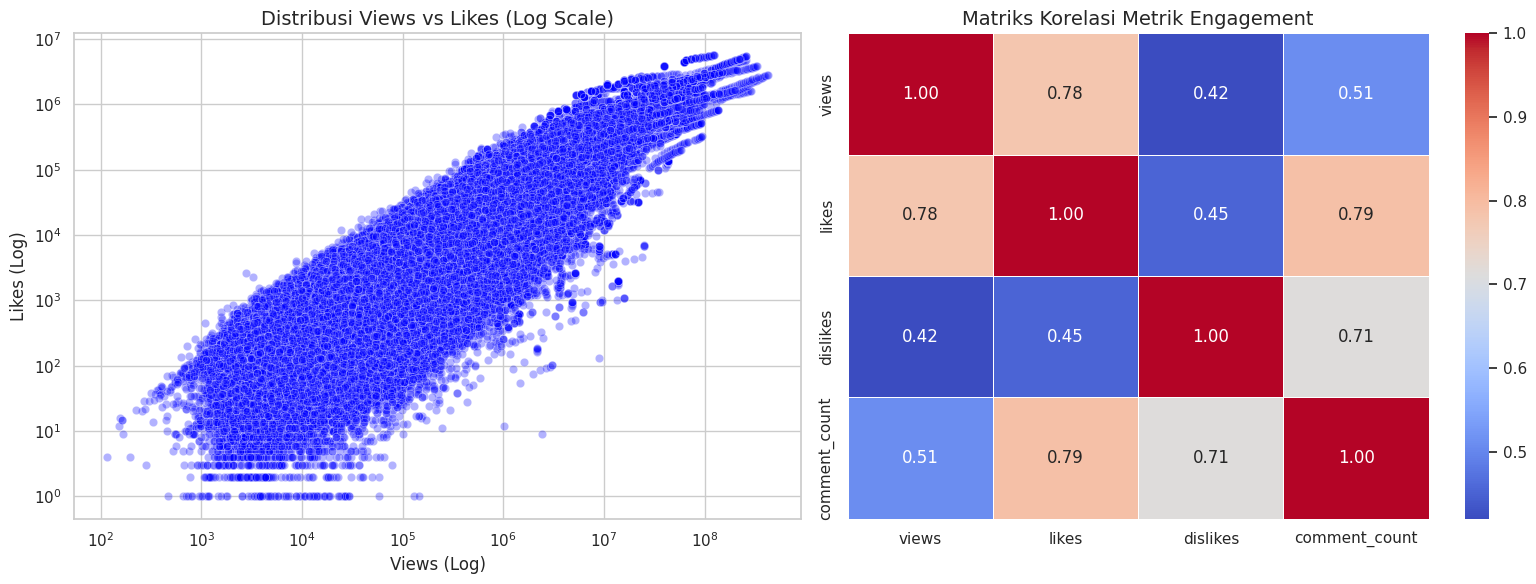

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_gabungan, x='views', y='likes', alpha=0.3, color='blue', ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Distribusi Views vs Likes (Log Scale)', fontsize=14)
axes[0].set_xlabel('Views (Log)')
axes[0].set_ylabel('Likes (Log)')

corr_cols = ['views', 'likes', 'dislikes', 'comment_count']
korelasi = df_gabungan[corr_cols].corr()

sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1])
axes[1].set_title('Matriks Korelasi Metrik Engagement', fontsize=14)

plt.tight_layout()
plt.show()

/tmp/ipykernel_555/2375809690.py:2: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



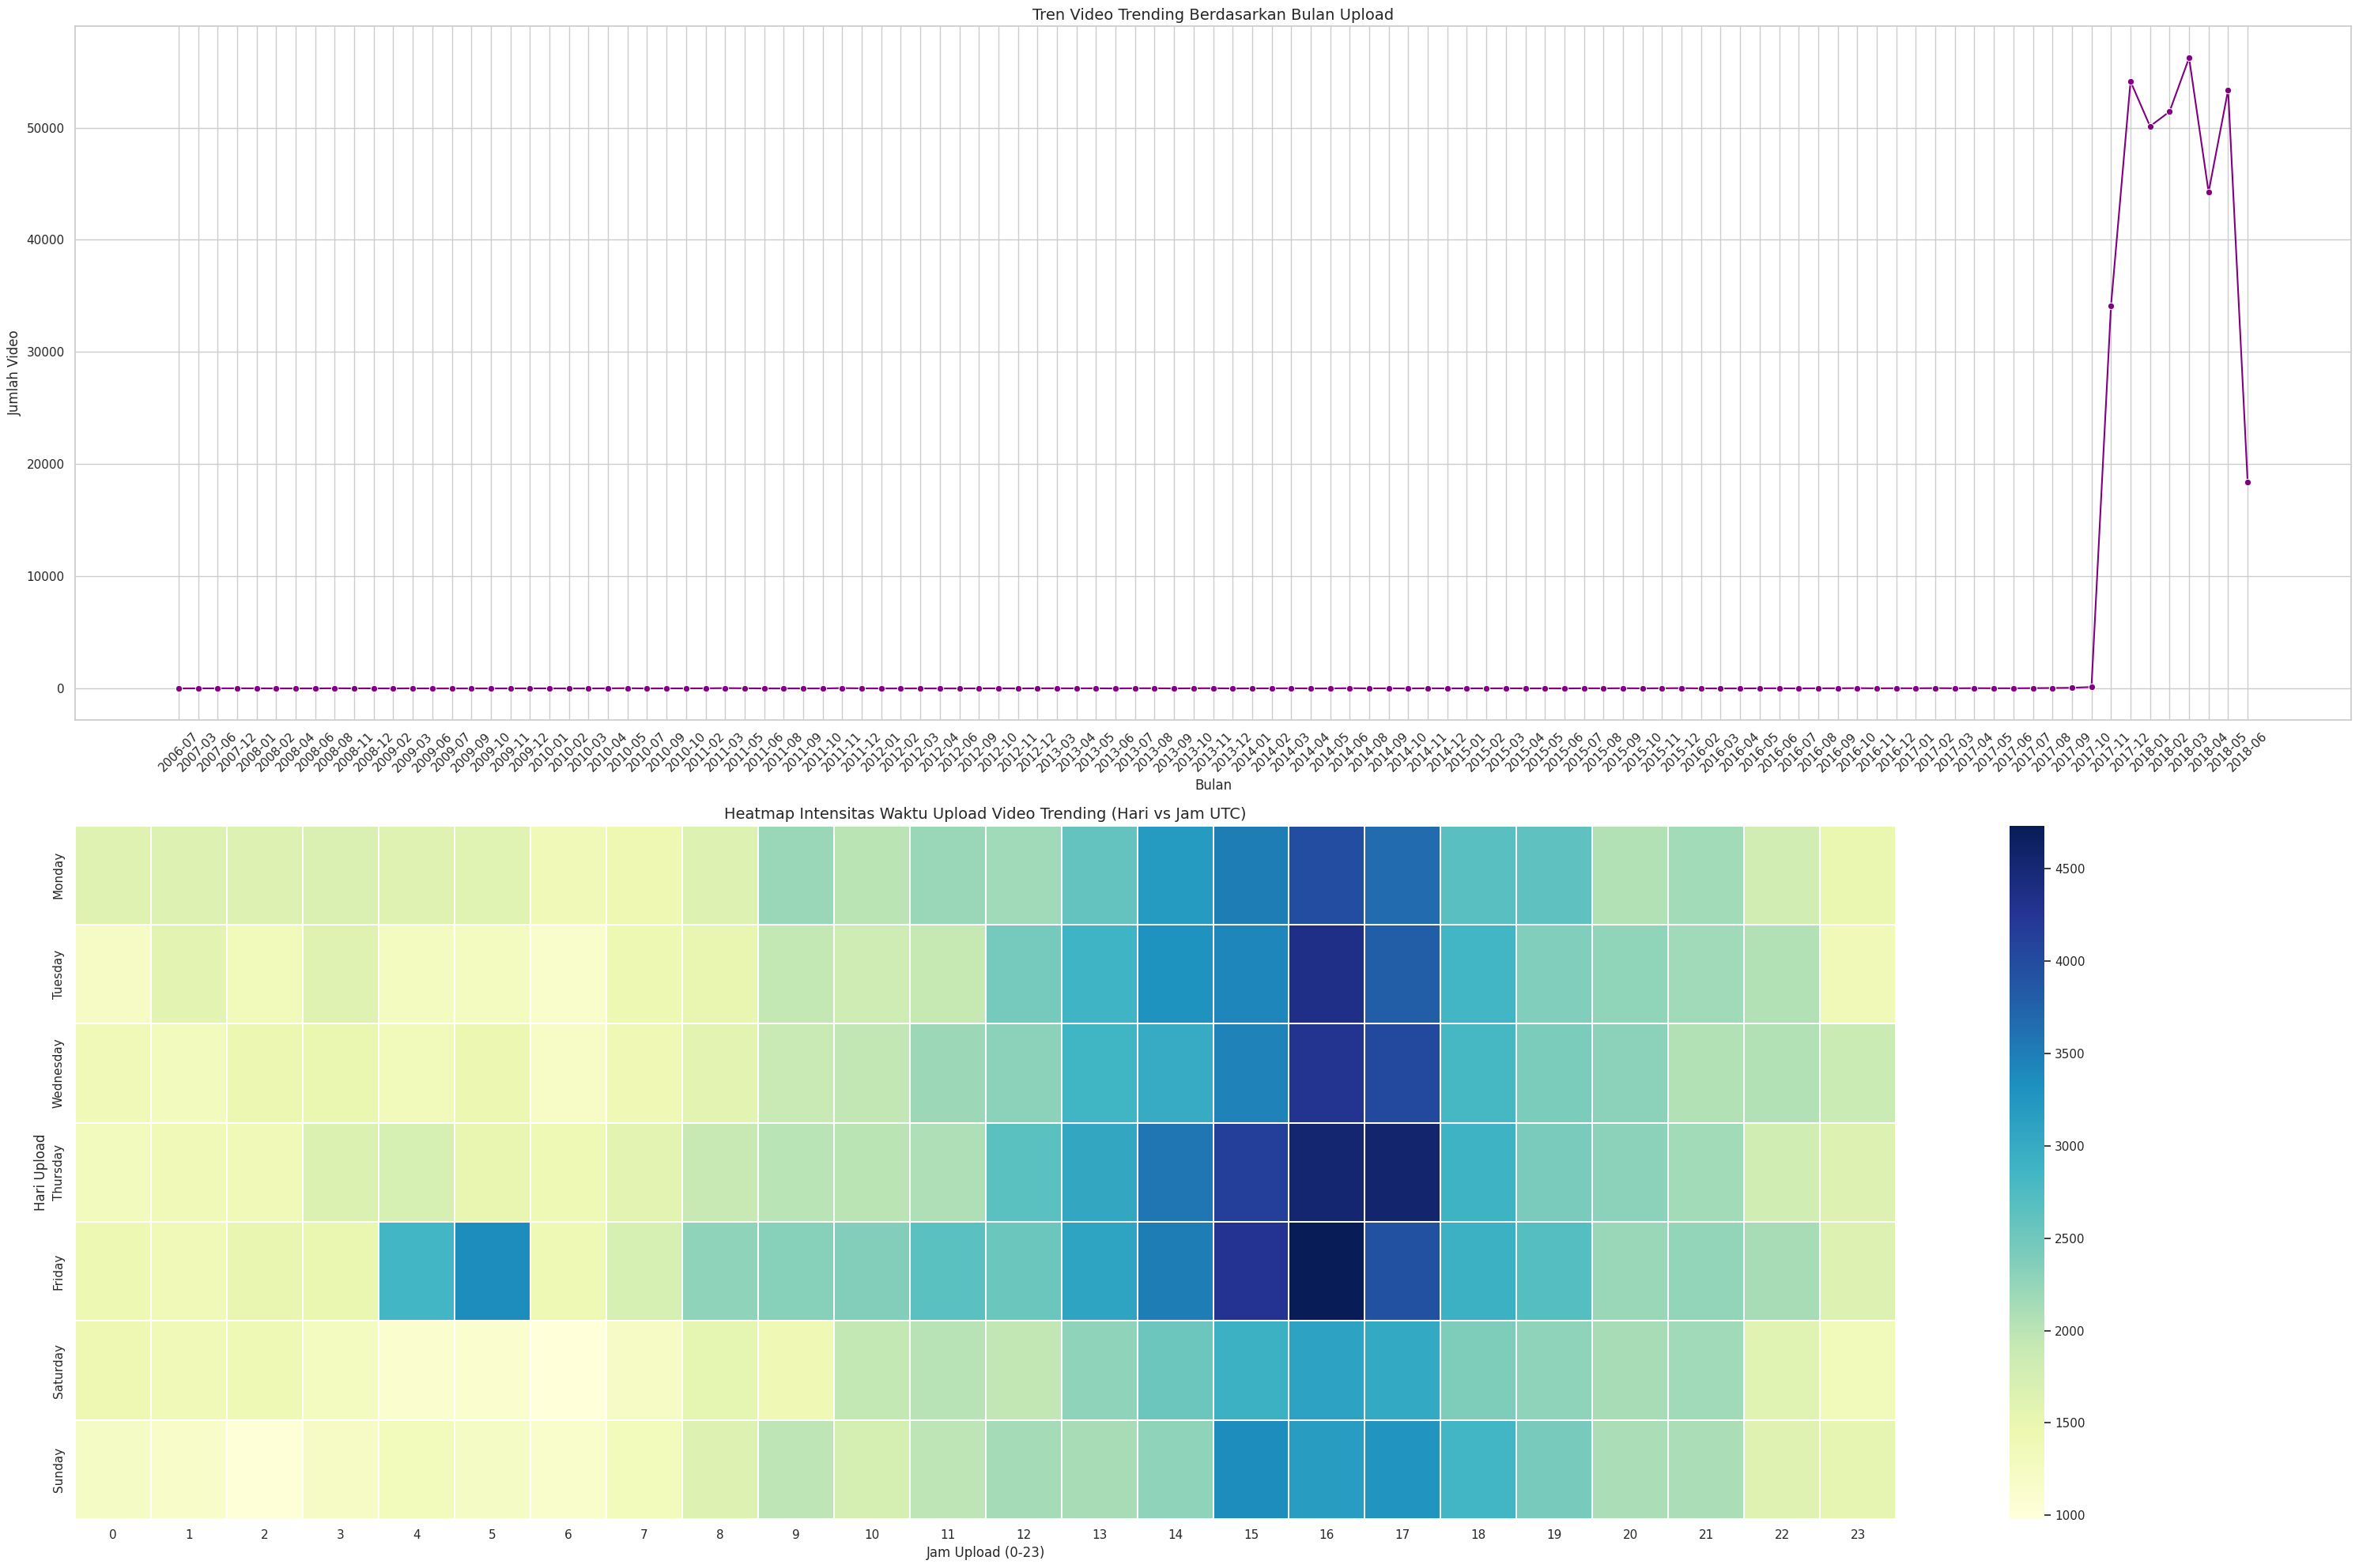

In [80]:
df_gabungan['publish_month'] = df_gabungan['publish_time'].dt.to_period('M')
df_gabungan['publish_day'] = df_gabungan['publish_time'].dt.day_name()
df_gabungan['publish_hour'] = df_gabungan['publish_time'].dt.hour

fig, axes = plt.subplots(2, 1, figsize=(30, 20))

tren_bulanan = df_gabungan.groupby('publish_month').size().reset_index(name='jumlah_video')
tren_bulanan['publish_month'] = tren_bulanan['publish_month'].astype(str) # Ubah ke string untuk sumbu X matplotlib

sns.lineplot(data=tren_bulanan, x='publish_month', y='jumlah_video', marker='o', color='purple', ax=axes[0])
axes[0].set_title('Tren Video Trending Berdasarkan Bulan Upload', fontsize=14)
axes[0].set_ylabel('Jumlah Video')
axes[0].set_xlabel('Bulan')
axes[0].tick_params(axis='x', rotation=45)

urutan_hari = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_waktu = df_gabungan.groupby(['publish_day', 'publish_hour']).size().unstack()
pivot_waktu = pivot_waktu.reindex(urutan_hari)

sns.heatmap(pivot_waktu, cmap='YlGnBu', linewidths=0.1, ax=axes[1])
axes[1].set_title('Heatmap Intensitas Waktu Upload Video Trending (Hari vs Jam UTC)', fontsize=14)
axes[1].set_ylabel('Hari Upload')
axes[1].set_xlabel('Jam Upload (0-23)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_555/2656328893.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




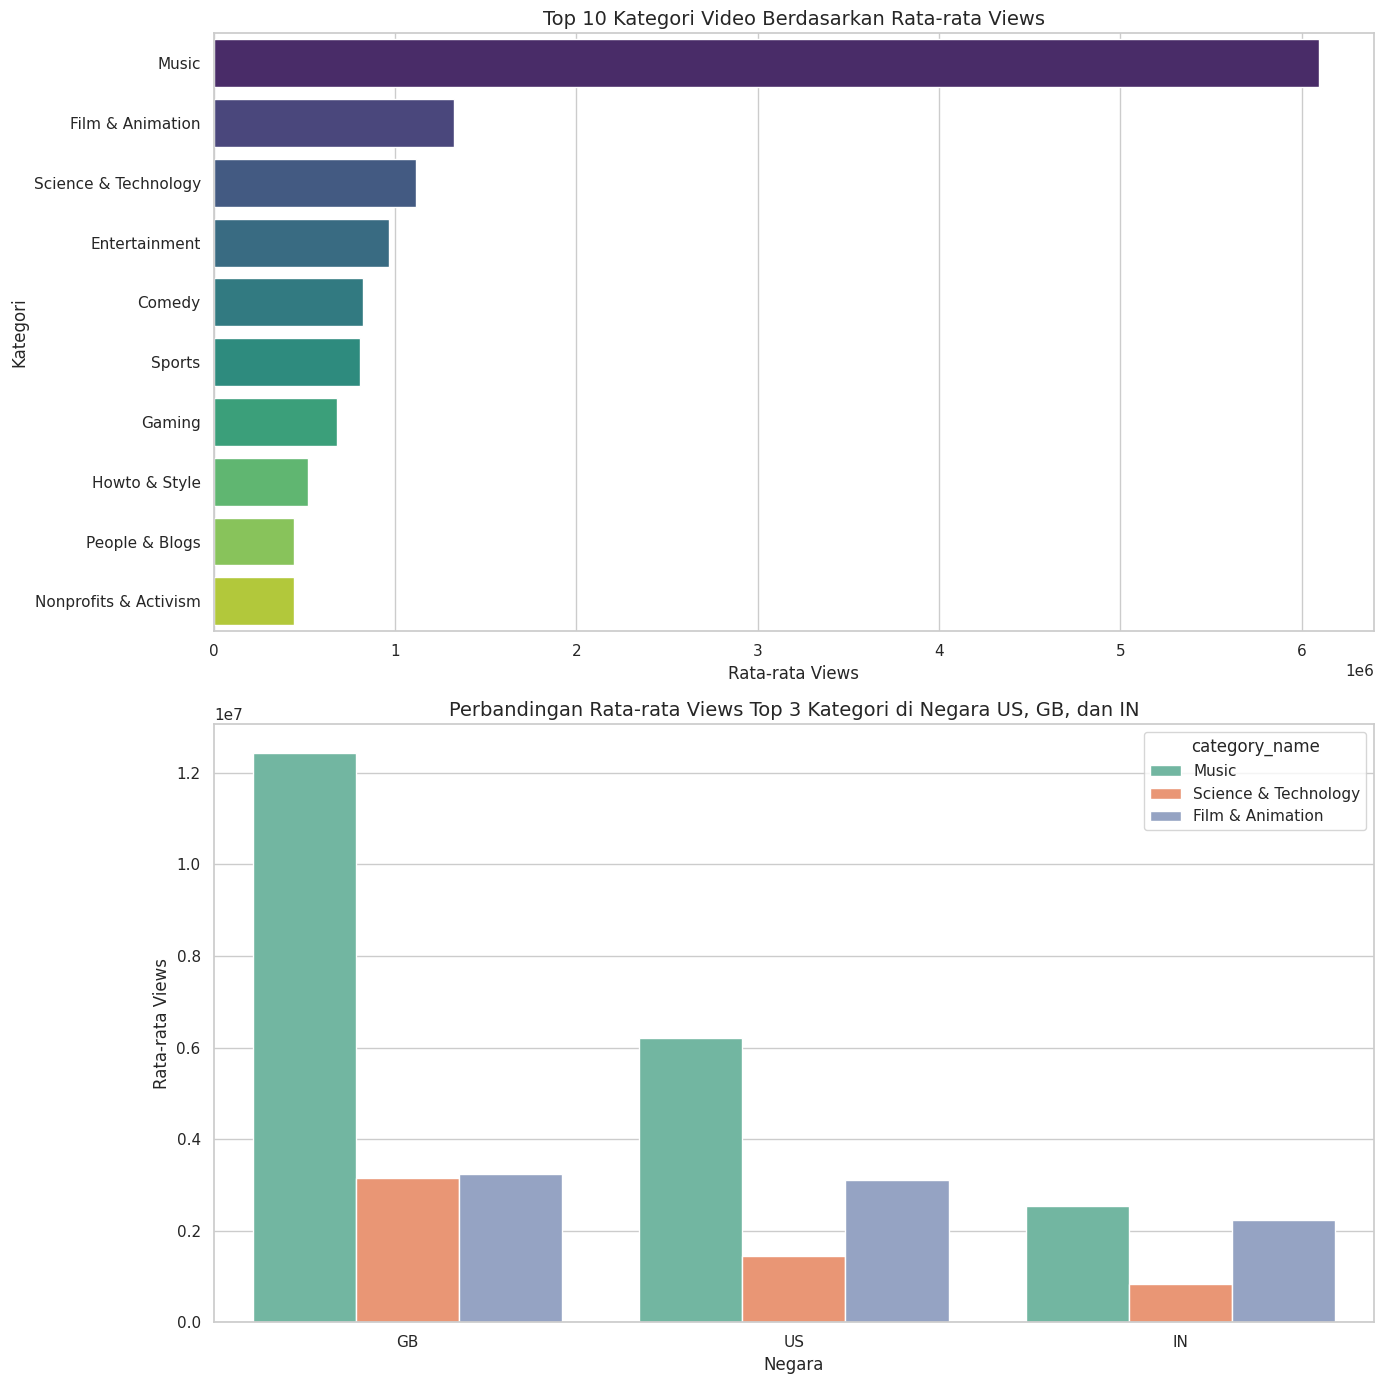

In [81]:
category_mapping = {
    1: 'Film & Animation', 2: 'Autos & Vehicles', 10: 'Music', 15: 'Pets & Animals',
    17: 'Sports', 19: 'Travel & Events', 20: 'Gaming', 22: 'People & Blogs',
    23: 'Comedy', 24: 'Entertainment', 25: 'News & Politics', 26: 'Howto & Style',
    27: 'Education', 28: 'Science & Technology', 29: 'Nonprofits & Activism'
}
df_gabungan['category_name'] = df_gabungan['category_id'].map(category_mapping)

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

top_categories = df_gabungan.groupby('category_name')['views'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Kategori Video Berdasarkan Rata-rata Views', fontsize=14)
axes[0].set_xlabel('Rata-rata Views')
axes[0].set_ylabel('Kategori')

top_3_cats = top_categories.head(3).index.tolist()
df_grouped = df_gabungan[
    (df_gabungan['country'].isin(['US', 'GB', 'IN'])) &
    (df_gabungan['category_name'].isin(top_3_cats))
]

sns.barplot(data=df_grouped, x='country', y='views', hue='category_name', palette='Set2', errorbar=None, ax=axes[1])
axes[1].set_title('Perbandingan Rata-rata Views Top 3 Kategori di Negara US, GB, dan IN', fontsize=14)
axes[1].set_xlabel('Negara')
axes[1].set_ylabel('Rata-rata Views')

plt.tight_layout()
plt.show()

In [82]:
df_map = df_gabungan.groupby('country')['views'].mean().reset_index()

df_map.columns = ['country_code', 'avg_views']

iso_mapping = {
    'US': 'USA', 'CA': 'CAN', 'GB': 'GBR', 'DE': 'DEU',
    'FR': 'FRA', 'RU': 'RUS', 'MX': 'MEX', 'IN': 'IND',
    'JP': 'JPN', 'KR': 'KOR'
}

country_names = {
    'US': 'United States', 'CA': 'Canada', 'GB': 'United Kingdom',
    'DE': 'Germany', 'FR': 'France', 'RU': 'Russia',
    'MX': 'Mexico', 'IN': 'India', 'JP': 'Japan', 'KR': 'South Korea'
}

df_map['iso_alpha'] = df_map['country_code'].map(iso_mapping)
df_map['country_name'] = df_map['country_code'].map(country_names)

fig = px.choropleth(
    df_map,
    locations="iso_alpha",
    color="avg_views",
    hover_name="country_name",
    color_continuous_scale=px.colors.sequential.Plasma,
    title="Peta Persebaran Rata-rata Views Video Trending YouTube",
    labels={'avg_views': 'Rata-rata Views'}
)

fig.update_geos(fitbounds="locations", showcountries=True)
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})

fig.show()